In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
        "Angle": info.get("Angle"),
        "av_dist_to_target": info.get("av_dist_to_target"),
        "Solution_EE_NJS_cropped" : info.get("EE_NJS_cropped"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

        joint_vels = {j: [] for j in joints}
        joint_times = []  # shared time axis (same for all joints)

        for p in points:
            vels = p.get("velocities", [])

            # ---- extract time_from_start ----
            t = p.get("time_from_start", None)

            if t is not None:
                # handle ROS Duration-like dict
                sec = t.get("sec", 0)
                nsec = t.get("nanosec", 0)
                t_sec = sec + nsec * 1e-9
            else:
                t_sec = np.nan  # fallback if missing

            joint_times.append(t_sec)

            # ---- velocities ----
            for j, v in zip(joints, vels):
                joint_vels[j].append(v)

        # store velocities + time
        for j in joints:
            row[f"{j}_vel"] = joint_vels[j]

        # shared time vector for plotting v(t)
        row["trajectory_time"] = joint_times

    rows.append(row)

df1 = pd.DataFrame(rows)
df1["failure"] = ~df1["converged"]

mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df1["projected_movement"] = np.where(
    df1["agent"] == 1,
    df1["movement"],
    df1.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)

print(df1.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          46      2      7     1    2      7-1       True  2.237922e+06   
1          37      2      7     9    1      7-9       True  4.941963e+06   
2          13      1      3     6    2      3-6       True  1.699652e+07   
3          39      2      7     1    2      7-1       True  1.858406e+06   
4          38      2      5     8    2      5-8       True  6.085110e+07   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105     7.976347e+05  ...   
1   86.883654     9.339444e+05  ...   
2  161.275011     5.979027e+05  ...   
3  119.390008     6.931827e+05  ...   
4  421.636214     1.649406e+06  ...   

                    sternoclavicular_pitch_joint_vel  \
0  [0.0, 0.0028101118390432347, 0.016198584560711...   
1  [0.0, 0.004143788709316837, 0.0177202069698855...   
2  [0.0, -1.1020649537388771, -0.6949419426246879...   
3  [0.0, 0.003769297970316325, 0.0172364813759873...   
4  [0.0, -0.0438894038742922

In [5]:
data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/benchmark")

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
        "Angle": info.get("Angle"),
        "av_dist_to_target": info.get("av_dist_to_target"),
        "Solution_EE_NJS_cropped" : info.get("EE_NJS_cropped"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

        joint_vels = {j: [] for j in joints}
        joint_times = []  # shared time axis (same for all joints)

        for p in points:
            vels = p.get("velocities", [])

            # ---- extract time_from_start ----
            t = p.get("time_from_start", None)

            if t is not None:
                # handle ROS Duration-like dict
                sec = t.get("sec", 0)
                nsec = t.get("nanosec", 0)
                t_sec = sec + nsec * 1e-9
            else:
                t_sec = np.nan  # fallback if missing

            joint_times.append(t_sec)

            # ---- velocities ----
            for j, v in zip(joints, vels):
                joint_vels[j].append(v)

        # store velocities + time
        for j in joints:
            row[f"{j}_vel"] = joint_vels[j]

        # shared time vector for plotting v(t)
        row["trajectory_time"] = joint_times

    rows.append(row)

df2 = pd.DataFrame(rows)
df2["failure"] = ~df2["converged"]

df2["projected_movement"] = np.where(
    df2["agent"] == 1,
    df2["movement"],
    df2.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)
print(df2.head())

   experiment  agent  start  goal  run movement  converged          NJS  \
0          46      2      7     1    2      7-1       True   707.092471   
1          37      2      7     9    1      7-9       True  3639.074037   
2          13      1      3     6    2      3-6       True   510.177404   
3          39      2      7     1    2      7-1       True  3560.981031   
4          38      2      5     8    2      5-8       True   379.182852   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105       356.557180  ...   
1   86.883654      2258.614772  ...   
2  161.275011       159.381189  ...   
3  119.390008      1437.600067  ...   
4  421.636214       475.326232  ...   

                    sternoclavicular_pitch_joint_vel  \
0  [0.0002834654255206871, 0.02834654255206858, 0...   
1  [-0.0010083228516606895, -0.10083228516606928,...   
2  [2.8570103954418223e-07, 2.857010395441789e-05...   
3  [0.00028398156735747826, 0.028398156735748064,...   
4  [-0.00020595471044863024, -0.02

  projected_movement        metric       value
0                1-3  Experimental  277.174742
1                1-3  Experimental  162.561163
2                1-3  Experimental   67.608141
3                1-3  Experimental  137.453590
4                1-3  Experimental  213.626895
['Experimental' 'Solver, from Waypoint 1' 'Solver']
(4831, 3)


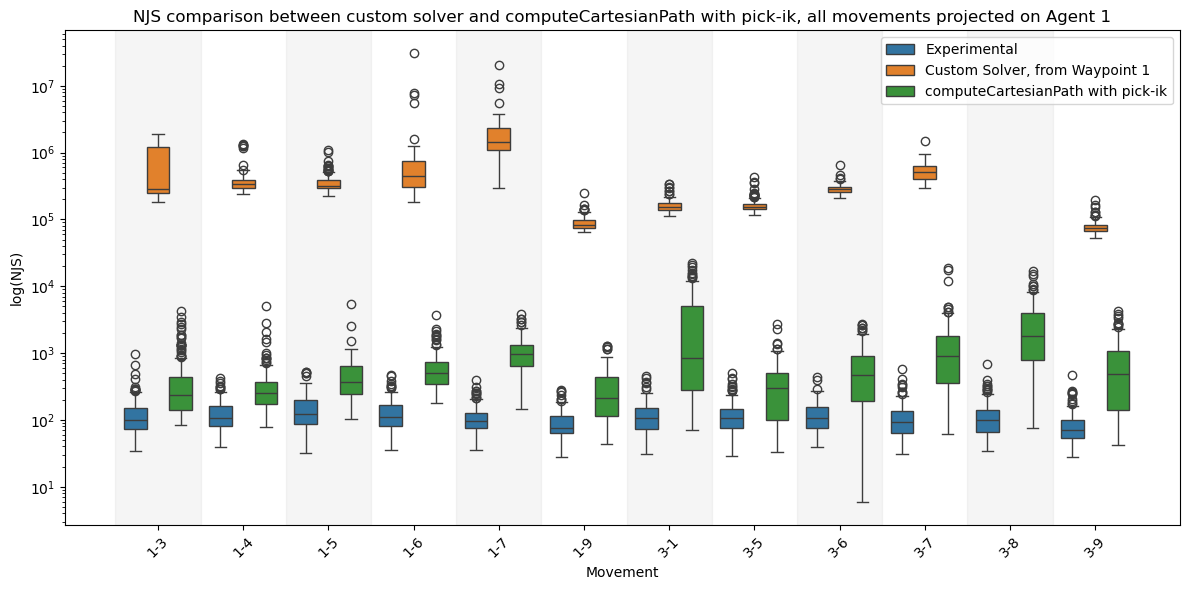

In [17]:
rows = []

# Experimental (only once, from df1)
for movement, group in df1.groupby("projected_movement"):
    for v in group["EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Experimental",
            "value": v
        })

# Solver from df1 (cropped)
for movement, group in df1.groupby("projected_movement"):
    converged = group[group["converged"]]

    for v in converged["Solution_EE_NJS_cropped"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solver, from Waypoint 1",
            "value": v
        })

# Solver from df2 (full)
for movement, group in df2.groupby("projected_movement"):
    converged = group[group["converged"]]

    for v in converged["Solution_EE_NJS"].dropna():
        rows.append({
            "projected_movement": movement,
            "metric": "Solver",
            "value": v
        })


long_df = pd.DataFrame(rows)

print(long_df.head())
print(long_df["metric"].unique())
print(long_df.shape)


plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=long_df,
    x="projected_movement",
    y="value",
    hue="metric",
    hue_order=[
        "Experimental",
        "Solver, from Waypoint 1",
        "Solver"
    ],
    showfliers=True
)


handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [
        "Experimental",
        "Custom Solver, from Waypoint 1",
        "computeCartesianPath with pick-ik"
    ]
)

ax.set_yscale("log")

x_labels = sorted(long_df["projected_movement"].unique())
for i, m in enumerate(x_labels):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color="gray", alpha=0.08)

plt.ylabel("log(NJS)")
plt.xlabel("Movement")
plt.xticks(rotation=45)
plt.title("NJS comparison between custom solver and computeCartesianPath with pick-ik, all movements projected on Agent 1")

plt.tight_layout()
plt.show()